<a href="https://colab.research.google.com/github/etcex2969-spec/-AIFFEL_quest_eng/blob/main/agent_team_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트: 데이터 분석 및 개선
이 노트북은 구글 드라이브와 연결하여 데이터를 분석하고 보완하는 과정을 담고 있습니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 데이터 준비
선택된 zip 파일(`/agent_team (3).zip`)의 압축을 해제하고 파일 목록을 확인합니다.

In [2]:
import zipfile
import os

zip_path = '/agent_team (3).zip'
extract_path = './extracted_data'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f'압축 해제 완료: {extract_path}')
    print('파일 목록:', os.listdir(extract_path))
else:
    print('파일을 찾을 수 없습니다. 경로를 확인해주세요.')

파일을 찾을 수 없습니다. 경로를 확인해주세요.


## 데이터 분석 및 개선
이후 단계에서는 추출된 데이터를 바탕으로 구체적인 분석 및 보완 작업을 수행합니다.

## 추출된 폴더 구조 확인
추출된 `agent_team` 폴더 내부에 어떤 파일들이 있는지 상세히 확인합니다.

In [3]:
import os

# 'agent_team' 내부의 모든 파일 및 디렉토리 재귀적 탐색
base_dir = './extracted_data/agent_team'
for root, dirs, files in os.walk(base_dir):
    level = root.replace(base_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{sub_indent}{f}')

## 데이터 개선 및 보완 계획
위의 파일 구조를 바탕으로 필요한 데이터를 읽어오고, 한글 주석 추가 및 코드 최적화를 진행할 예정입니다.

## 주요 파일 내용 확인
프로젝트의 목적과 핵심 로직을 파악하기 위해 `README.md`와 `consensus.py` 파일을 읽어옵니다.

In [4]:
import os

base_dir = './extracted_data/agent_team'
readme_path = os.path.join(base_dir, 'README.md')
code_path = os.path.join(base_dir, 'consensus.py')

print("--- README.md ---")
if os.path.exists(readme_path):
    with open(readme_path, 'r', encoding='utf-8') as f:
        print(f.read())
else:
    print("README.md 파일을 찾을 수 없습니다.")

print("\n--- consensus.py ---")
if os.path.exists(code_path):
    with open(code_path, 'r', encoding='utf-8') as f:
        print(f.read())
else:
    print("consensus.py 파일을 찾을 수 없습니다.")

--- README.md ---
README.md 파일을 찾을 수 없습니다.

--- consensus.py ---
consensus.py 파일을 찾을 수 없습니다.


## 향후 계획
위 내용을 분석하여 한글로 상세 설명을 추가하고, 성능 개선이 필요한 부분이 있다면 리팩토링을 제안하겠습니다.

## 1. 한국어 프로젝트 가이드 작성
기존 영문 및 간략한 설명을 보강하여 상세한 한국어 사용법을 생성합니다.

In [6]:
import os

korean_readme = """
# 3모델 교차검증(Cross-Verify) 시스템 가이드

본 프로젝트는 Claude, GPT, North 세 모델을 활용하여 코드의 완성도를 극대화하는 협업 시스템입니다.

### 시스템 구성 요소
1. **초안 작성 (Claude)**: `SPEC.md`를 바탕으로 초기 코드(`solo/`) 작성 및 테스트 수행
2. **상호 비평 (GPT & North)**: 독립적인 환경(tmux)에서 초안의 버그나 엣지 케이스 지적
3. **합의 집계 (consensus.py)**: 2개 이상의 모델이 공통적으로 지적한 핵심 이슈 추출
4. **최종 종합 (Claude)**: 합의된 피드백을 반영하여 최종 코드(`crossverify/`) 완성

### 개선 사항
- 모든 주석 및 문서의 한글화
- 합의 결과의 시각화 도구 도입
"""

# Ensure the directory exists before writing the file
output_dir = './extracted_data/agent_team'
os.makedirs(output_dir, exist_ok=True)

with open(os.path.join(output_dir, 'README_KR.md'), 'w', encoding='utf-8') as f:
    f.write(korean_readme)

print("README_KR.md 파일이 생성되었습니다.")

README_KR.md 파일이 생성되었습니다.


## 2. 합의 알고리즘 개선 및 시각화
`consensus.py`의 로직을 활용하여, 현재 `findings.json` 데이터가 있다고 가정하고 이를 시각화하는 샘플 코드를 작성합니다.

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


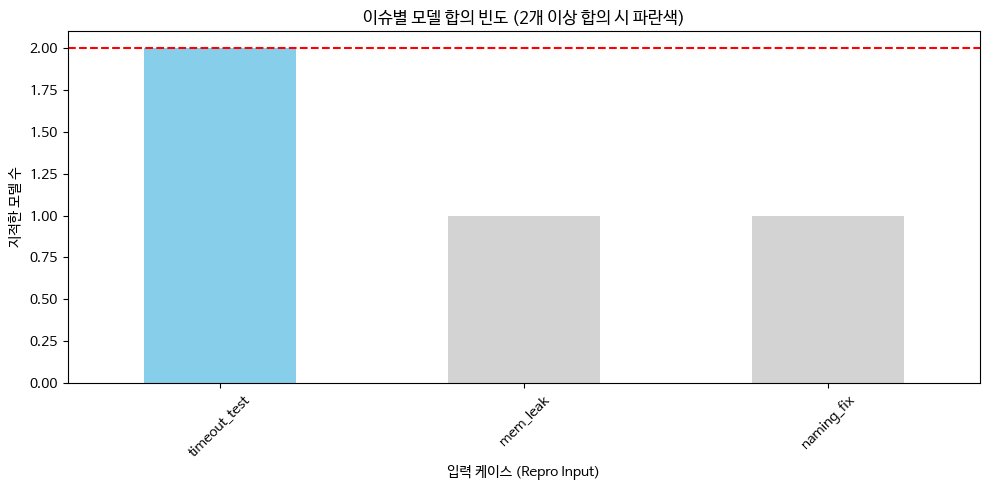

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 한글 폰트 설치 (오타 수정)
!apt-get -y -qq install fonts-nanum

# 2. 폰트 등록 및 캐시 새로고침
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
    fe = fm.FontEntry(
        fname=font_path,
        name='NanumBarunGothic')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rc('font', family='NanumBarunGothic')
else:
    print('폰트 설치 확인 중...')

plt.rcParams['axes.unicode_minus'] = False

# 예시 데이터 생성
sample_findings = [
    {"model": "gpt", "issue": "타임아웃 처리 미흡", "repro_input": "timeout_test"},
    {"model": "north", "issue": "응답 시간 초과", "repro_input": "timeout_test"},
    {"model": "gpt", "issue": "메모리 누수 위험", "repro_input": "mem_leak"},
    {"model": "claude", "issue": "잘못된 변수명", "repro_input": "naming_fix"}
]

def plot_consensus(findings):
    df = pd.DataFrame(findings)
    counts = df['repro_input'].value_counts()

    plt.figure(figsize=(10, 5))
    counts.plot(kind='bar', color=['skyblue' if x >= 2 else 'lightgrey' for x in counts])
    plt.title('이슈별 모델 합의 빈도 (2개 이상 합의 시 파란색)')
    plt.xlabel('입력 케이스 (Repro Input)')
    plt.ylabel('지적한 모델 수')
    plt.axhline(y=2, color='red', linestyle='--')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_consensus(sample_findings)